# SBND double-anode SCE / E-field map (`sbnd_sce_doubleanode_2d_v10c.root`)

Inspect the new cathode-study map from `gputnam`, now shipped in the cafpyana repo:

```
data/efield/sbnd_sce_doubleanode_2d_v10c.root
```

(Original source: `/exp/sbnd/app/users/gputnam/cathode-study/sce_input_doubleanode_2d/`.)

Format differences w.r.t. the previous `SBND_DataMap_v3.root` (see `detector_Efield.ipynb`):

- Same TH3F grid: 49 x 49 x 61 bins over x, y in [-204.167, 204.167] cm and z in [-4.167, 504.167] cm.
- **No `_E` / `_W` TPC split** — a single set of histograms covers the whole detector.
  (In the old map the `*_E` and `*_W` histograms were byte-identical anyway.)
- Same value convention: `True_ElecField_{X,Y,Z}` are *fractional* E-field offsets
  (LArSoft convention) and `True_ElecField_Mag = sqrt((1+fx)^2 + fy^2 + fz^2) - 1`,
  i.e. the fractional change of |E|. Verified numerically below.
- Distortions are much larger than the old map (|E| fraction from about -20% to +60%,
  vs. a few percent before), concentrated around the cathode (x = 0).

In [1]:
import numpy as np
import uproot
import matplotlib.pyplot as plt

plt.style.use("presentation.mplstyle")

In [2]:
from os import path

# Repo-local copy used by makedf (grid-safe). Falls back to original path if needed.
# Notebook CWD is usually notebooks/; resolve relative to cafpyana root.
_CAFPYANA_ROOT = path.abspath(path.join("..", "..", ".."))
ROOT_PATH = path.join(_CAFPYANA_ROOT, "data", "efield", "sbnd_sce_doubleanode_2d_v10c.root")
if not path.isfile(ROOT_PATH):
    ROOT_PATH = (
        "/exp/sbnd/app/users/gputnam/cathode-study/"
        "sce_input_doubleanode_2d/sbnd_sce_doubleanode_2d_v10c.root"
    )

root_file = uproot.open(ROOT_PATH)

print(f"File: {ROOT_PATH}")
print(f"Objects ({len(root_file.keys())}):")
for key, classname in root_file.classnames().items():
    print(f"  {key:32s} {classname}")

File: /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/data/efield/sbnd_sce_doubleanode_2d_v10c.root
Objects (10):
  TrueFwd_Displacement_X;1         TH3F
  TrueFwd_Displacement_Y;1         TH3F
  TrueFwd_Displacement_Z;1         TH3F
  TrueBkwd_Displacement_X;1        TH3F
  TrueBkwd_Displacement_Y;1        TH3F
  TrueBkwd_Displacement_Z;1        TH3F
  True_ElecField_X;1               TH3F
  True_ElecField_Y;1               TH3F
  True_ElecField_Z;1               TH3F
  True_ElecField_Mag;1             TH3F


In [3]:
def hist_axis_info(axis):
    return {
        "nbins": axis.member("fNbins"),
        "xmin": axis.member("fXmin"),
        "xmax": axis.member("fXmax"),
    }


def summarize_th3(hist):
    vals = hist.values()
    nz = vals[vals != 0]
    return {
        "shape": vals.shape,
        "x": hist_axis_info(hist.member("fXaxis")),
        "y": hist_axis_info(hist.member("fYaxis")),
        "z": hist_axis_info(hist.member("fZaxis")),
        "nonzero_bins": int(np.count_nonzero(vals)),
        "min": float(np.min(nz)) if nz.size else np.nan,
        "max": float(np.max(nz)) if nz.size else np.nan,
    }


hist_keys = sorted(root_file.keys())
summaries = {key: summarize_th3(root_file[key]) for key in hist_keys}

ref = summaries[hist_keys[0]]
print("Common grid (all histograms share the same binning):")
for axis in ("x", "y", "z"):
    info = ref[axis]
    print(
        f"  {axis.upper():1s}: {info['nbins']:3d} bins, "
        f"[{info['xmin']:8.3f}, {info['xmax']:8.3f}] cm"
    )

print("\nPer-histogram value ranges (nonzero bins only):")
for key in hist_keys:
    s = summaries[key]
    print(
        f"  {key.split(';')[0]:28s}  nonzero={s['nonzero_bins']:6d}/{np.prod(s['shape'])}"
        f"  min={s['min']: .6g}  max={s['max']: .6g}"
    )

Common grid (all histograms share the same binning):
  X:  49 bins, [-204.167,  204.167] cm
  Y:  49 bins, [-204.167,  204.167] cm
  Z:  61 bins, [  -4.167,  504.167] cm

Per-histogram value ranges (nonzero bins only):
  TrueBkwd_Displacement_X       nonzero=140483/146461  min=-3.58028  max= 6.88162
  TrueBkwd_Displacement_Y       nonzero=140483/146461  min=-4.46909  max= 4.13925
  TrueBkwd_Displacement_Z       nonzero=140483/146461  min=-3.10528  max= 4.61246
  TrueFwd_Displacement_X        nonzero=140483/146461  min=-6.90175  max= 3.60325
  TrueFwd_Displacement_Y        nonzero=140483/146461  min=-4.18713  max= 4.73434
  TrueFwd_Displacement_Z        nonzero=140483/146461  min=-4.66151  max= 3.12131
  True_ElecField_Mag            nonzero=146461/146461  min=-0.201269  max= 0.600893
  True_ElecField_X              nonzero=146461/146461  min=-0.204529  max= 0.598242
  True_ElecField_Y              nonzero=146461/146461  min=-0.104153  max= 0.0718618
  True_ElecField_Z              nonz

## Value convention check

Confirm that `True_ElecField_Mag` is the fractional change of the field magnitude,
assuming `True_ElecField_{X,Y,Z}` are fractional offsets w.r.t. the nominal drift field
(LArSoft `GetCalEfieldOffsets` convention):

\[ \texttt{Mag} = \sqrt{(1 + f_x)^2 + f_y^2 + f_z^2} - 1 \]

so that \( E_{\mathrm{distorted}} = E_0 \, (1 + \texttt{Mag}) \).

In [4]:
fx = root_file["True_ElecField_X"].values()
fy = root_file["True_ElecField_Y"].values()
fz = root_file["True_ElecField_Z"].values()
mag = root_file["True_ElecField_Mag"].values()

mag_from_frac = np.sqrt((1 + fx) ** 2 + fy**2 + fz**2) - 1
mag_from_abs = np.sqrt(fx**2 + fy**2 + fz**2)

print("max |Mag - (sqrt((1+fx)^2+fy^2+fz^2)-1)| :", np.abs(mag - mag_from_frac).max())
print("max |Mag - sqrt(fx^2+fy^2+fz^2)|         :", np.abs(mag - mag_from_abs).max())
print()
print("=> Mag is the fractional |E| change; E_new = E_nominal * (1 + Mag)")

max |Mag - (sqrt((1+fx)^2+fy^2+fz^2)-1)| : 1.9557774e-07
max |Mag - sqrt(fx^2+fy^2+fz^2)|         : 0.41813055

=> Mag is the fractional |E| change; E_new = E_nominal * (1 + Mag)


In [5]:
def th3_axis_edges(axis):
    nbins = axis.member("fNbins")
    return np.linspace(axis.member("fXmin"), axis.member("fXmax"), nbins + 1)


def th3_axis_centers(axis):
    edges = th3_axis_edges(axis)
    return 0.5 * (edges[:-1] + edges[1:])


def load_th3(key):
    hist = root_file[key]
    return {
        "values": hist.values(),
        "x": th3_axis_centers(hist.member("fXaxis")),
        "y": th3_axis_centers(hist.member("fYaxis")),
        "z": th3_axis_centers(hist.member("fZaxis")),
        "x_edges": th3_axis_edges(hist.member("fXaxis")),
        "y_edges": th3_axis_edges(hist.member("fYaxis")),
        "z_edges": th3_axis_edges(hist.member("fZaxis")),
    }


efield_mag = load_th3("True_ElecField_Mag")
print("Loaded: True_ElecField_Mag")
print("  shape:", efield_mag["values"].shape)
print("  x range [cm]:", efield_mag["x"][0], "->", efield_mag["x"][-1])
print("  z range [cm]:", efield_mag["z"][0], "->", efield_mag["z"][-1])

Loaded: True_ElecField_Mag
  shape: (49, 49, 61)
  x range [cm]: -200.0000003265306 -> 200.0000003265306
  z range [cm]: -3.278688520680362e-07 -> 500.00000032786886


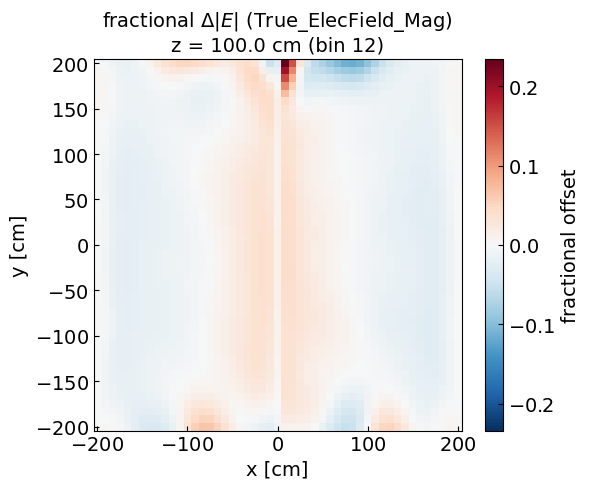

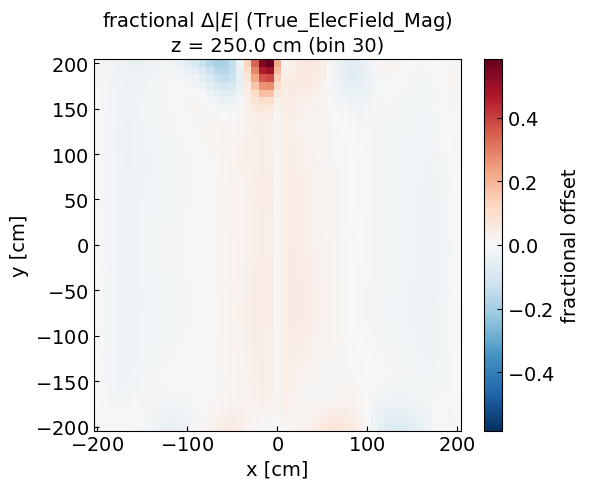

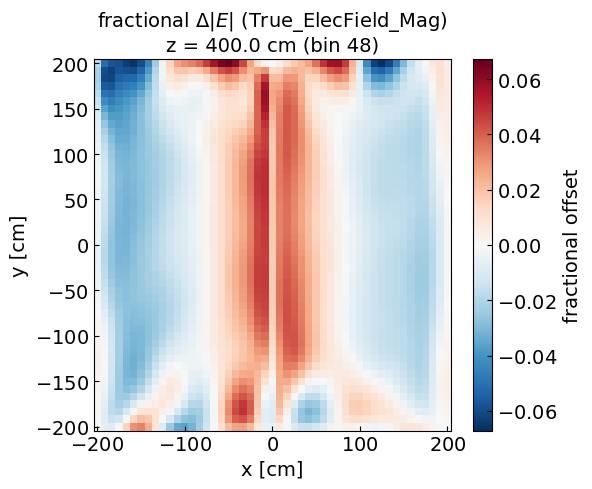

In [6]:
def plot_th3_xy_slice(data, z_cm, title="", cmap="RdBu_r", symmetric=True):
    """Plot the x-y slice of a TH3 at the z bin nearest to z_cm."""
    vals = data["values"]
    iz = int(np.argmin(np.abs(data["z"] - z_cm)))
    slice_xy = vals[:, :, iz].T

    vmax = np.max(np.abs(slice_xy)) if symmetric else None
    vmin = -vmax if symmetric else None

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(
        data["x_edges"], data["y_edges"], slice_xy,
        shading="auto", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(f"{title}\nz = {data['z'][iz]:.1f} cm (bin {iz})")
    fig.colorbar(im, ax=ax, label="fractional offset")
    fig.tight_layout()
    return fig, ax


for z_cm in (100.0, 250.0, 400.0):
    plot_th3_xy_slice(efield_mag, z_cm=z_cm, title="fractional $\\Delta|E|$ (True_ElecField_Mag)")
    plt.show()

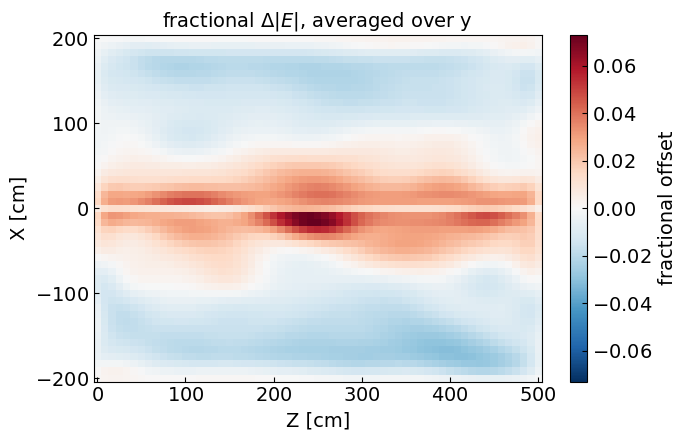

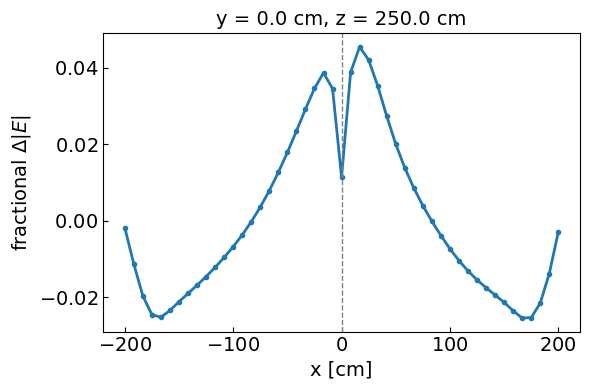

In [8]:
# x-z view (averaged over y) -- shows the cathode (x=0) structure along the beam direction
vals = efield_mag["values"]
xz = vals.mean(axis=1)  # average over y; transpose so z is on the vertical axis

fig, ax = plt.subplots(figsize=(7, 4.5))
vmax = np.max(np.abs(xz))
im = ax.pcolormesh(
    efield_mag["z_edges"], efield_mag["x_edges"], xz,
    shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)
ax.set_xlabel("Z [cm]")
ax.set_ylabel("X [cm]")
ax.set_title("fractional $\\Delta|E|$, averaged over y")
fig.colorbar(im, ax=ax, label="fractional offset")
fig.tight_layout()
plt.show()

# 1D profile vs x at detector center
iy = vals.shape[1] // 2
iz = vals.shape[2] // 2
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(efield_mag["x"], vals[:, iy, iz], marker=".")
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("x [cm]")
ax.set_ylabel("fractional $\\Delta|E|$")
# ax.set_title(f"y = {efield_mag['y'][iy]:.1f} cm, z = {efield_mag['z'][iz]:.1f} cm")
ax.set_title(f"y = {np.abs(efield_mag['y'][iy]):.1f} cm, z = {efield_mag['z'][iz]:.1f} cm")
fig.tight_layout()
plt.show()

## Comparison with the old map (`SBND_DataMap_v3.root`)

The old map stored one histogram per TPC (`*_E`, `*_W`), but the two were identical.
Compare the E/W-merged old |E| fractional map with the new one.

old map: max |Mag_E - Mag_W| = 0.0


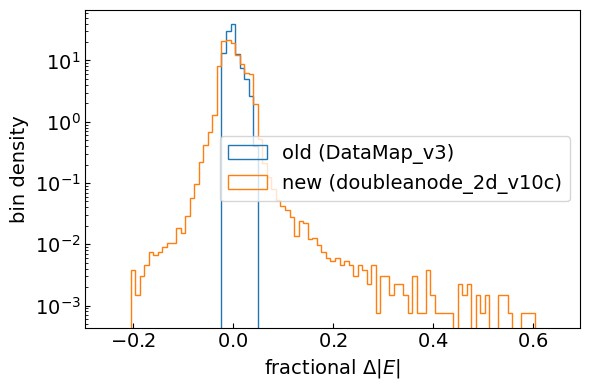

old: min=-0.02038, max=0.04355
new: min=-0.2013, max=0.6009


In [8]:
OLD_ROOT_PATH = (
    "/exp/sbnd/app/users/jaz8600/CathodeSimulation/"
    "localProducts_larsoft_v10_06_00_02_e26_prof/sbnd_data/v01_99/"
    "SCEoffsets/SBND_DataMap_v3.root"
)
old_file = uproot.open(OLD_ROOT_PATH)

old_mag_E = old_file["True_ElecField_Mag_E"].values()
old_mag_W = old_file["True_ElecField_Mag_W"].values()
print("old map: max |Mag_E - Mag_W| =", np.abs(old_mag_E - old_mag_W).max())

new_mag = efield_mag["values"]

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(-0.25, 0.65, 100)
ax.hist(old_mag_E.ravel(), bins=bins, histtype="step", label="old (DataMap_v3)", density=True)
ax.hist(new_mag.ravel(), bins=bins, histtype="step", label="new (doubleanode_2d_v10c)", density=True)
ax.set_xlabel("fractional $\\Delta|E|$")
ax.set_ylabel("bin density")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

print(f"old: min={old_mag_E.min():.4g}, max={old_mag_E.max():.4g}")
print(f"new: min={new_mag.min():.4g}, max={new_mag.max():.4g}")

## Interpolator sanity check (as used in `makedf.makedf._apply_sbnd_efield_map`)

The workflow builds a single `RegularGridInterpolator` over bin centers of
`True_ElecField_Mag` and evaluates it at hit positions:
`efield_new = efield * (1 + interp(x, y, z))`.

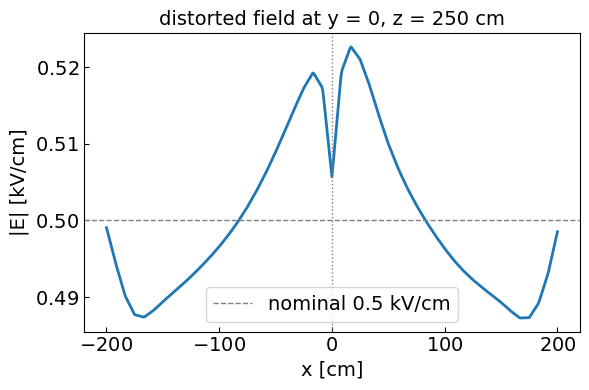

delta range along this line: [-0.0254, 0.0453]


In [9]:
from scipy.interpolate import RegularGridInterpolator

interp = RegularGridInterpolator(
    (efield_mag["x"], efield_mag["y"], efield_mag["z"]),
    np.asarray(efield_mag["values"], dtype=float),
    bounds_error=False,
    fill_value=0.0,
)

# evaluate on a fine grid across the drift direction at detector center
x_fine = np.linspace(-200, 200, 401)
pts = np.column_stack([x_fine, np.zeros_like(x_fine), np.full_like(x_fine, 250.0)])
delta = interp(pts)

E0 = 0.5  # kV/cm nominal SBND drift field
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine, E0 * (1 + delta))
ax.axhline(E0, color="gray", ls="--", lw=1, label="nominal 0.5 kV/cm")
ax.axvline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("x [cm]")
ax.set_ylabel("|E| [kV/cm]")
ax.set_title("distorted field at y = 0, z = 250 cm")
ax.legend()
fig.tight_layout()
plt.show()

print(f"delta range along this line: [{delta.min():.4f}, {delta.max():.4f}]")